# DSC550-T301 Data Mining (2255-1)
## MILESTONE 1: DATA SELECTION AND EDA
### Linh Huynh

#### Project Idea and Problem

For this data mining project, I have chosen to analyze the IBM HR Analytics Employee Attrition & Performance dataset (https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset). This dataset contains detailed information about employees, such as their job satisfaction levels, salary, number of years at the company, and performance scores. The key feature of this dataset is the Attrition column, which indicates whether an employee has left the company or not. Employee attrition, or turnover, is a critical issue for many businesses, as it can be costly and disruptive. Understanding the factors that contribute to employee turnover is essential for human resources (HR) teams to address potential problems before they lead to resignations.

The goal of this project is to build a model that can predict employee attrition based on various factors, helping businesses understand why employees leave and how to take action to prevent it. In addition to building a predictive model, this analysis will help identify the most important features that influence attrition. By focusing on factors like job satisfaction, work-life balance, and tenure at the company, HR departments can gain insights into how they can improve employee engagement and retention.

This project will be approached as a binary classification problem, where the model will predict whether an employee is likely to stay or leave, based on the other features in the dataset. This type of model can be a valuable tool for HR departments, allowing them to proactively address issues that contribute to employee attrition and create a more supportive and engaging workplace.

#### Graphical Analysis 

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('/Users/linhhuynh/Desktop/DSC550/dtbases/HR-Employee-Attrition.csv')
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Print shape and datatype 
print("\nShape of the DataFrame:")
print(df.shape)
print("\nData types:")
df.dtypes


Shape of the DataFrame:
(1470, 35)

Data types:


Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [6]:
# Check for missing values
print("\nMissing values in each column:")
df.isnull().sum()


Missing values in each column:


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
# Check for duplicates rows
print("\nNumber of duplicate rows:")
df.duplicated().sum()


Number of duplicate rows:


0

After checking for missing values and duplicate rows, the dataset is clean and ready for analysis. 

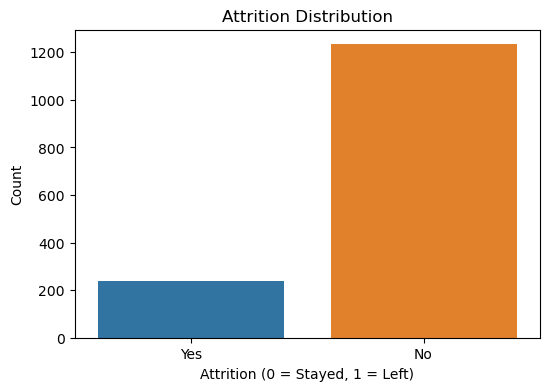

In [9]:
# Distribution of Attrition (Target Variable)
# This shows how many employees stayed vs. left
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
plt.ylabel('Count')
plt.show()

The number of employees who stayed is greater than those who left. Approximately more than 200 (about 16%) of the total 1,470 employees have left the company both voluntarily and involuntarily including resignation, retirement, termination, ect. 

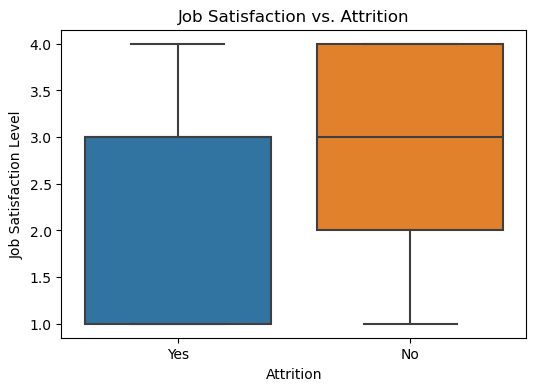

In [11]:
# Satisfaction Level vs. Attrition
# Explore if employees with lower job satisfaction are more likely to leave
plt.figure(figsize=(6, 4))
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df)
plt.title('Job Satisfaction vs. Attrition')
plt.xlabel('Attrition')
plt.ylabel('Job Satisfaction Level')
plt.show()

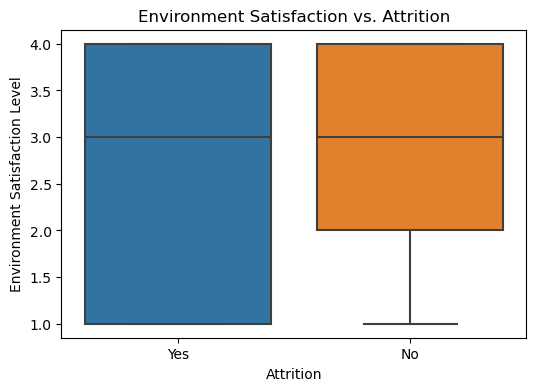

In [12]:
# Explore if employees with lower Environment Satisfaction are more likely to leave
plt.figure(figsize=(6, 4))
sns.boxplot(x='Attrition', y='EnvironmentSatisfaction', data=df)
plt.title('Environment Satisfaction vs. Attrition')
plt.xlabel('Attrition')
plt.ylabel('Environment Satisfaction Level')
plt.show()

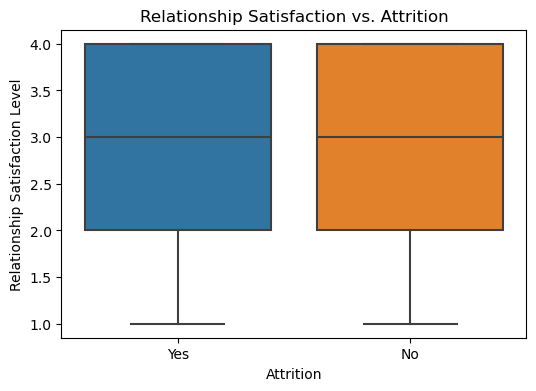

In [13]:
# Explore if employees with lower Relationship Satisfaction are more likely to leave
plt.figure(figsize=(6, 4))
sns.boxplot(x='Attrition', y='RelationshipSatisfaction', data=df)
plt.title('Relationship Satisfaction vs. Attrition')
plt.xlabel('Attrition')
plt.ylabel('Relationship Satisfaction Level')
plt.show()

- Job Satisfaction vs. Attrition:
Employees who left the company had a lower job satisfaction on average. Their scores are more spread out and lower compared to those who stayed.

- Environment Satisfaction vs. Attrition:
Similar to job satisfaction, employees who left also had lower environment satisfaction. The range of scores is wider for those who left, and their median is lower.

- Relationship Satisfaction vs. Attrition:
In this chart, both groups (left and stayed) look very similar. Their satisfaction levels are nearly the same, which means relationship satisfaction might not affect attrition as much as the other two.

Employees who are not happy with their job or work environment are more likely to leave the company. But their relationship satisfaction does not show a big difference. So, job satisfaction and environment satisfaction are more important reasons for why people leave. Managers should focus on improving these areas to keep employees.

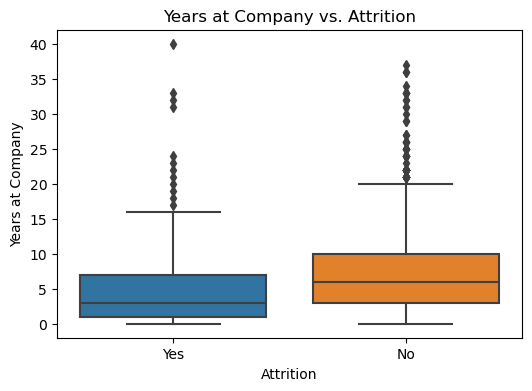

In [17]:
# Years at Company vs. Attrition
# Explore if employees who leave have spent fewer years at the company
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company vs. Attrition')
plt.xlabel('Attrition')
plt.ylabel('Years at Company')
plt.show()

The boxplot shows that employees who leave the company usually have fewer years at the company compared to those who stay. Most employees who left had worked for about 3 to 4 years, while those who stayed had a median of around 7 to 8 years. This suggests that employees are more likely to leave during the early years of their employment. There are also more long-term employees in the group that stayed. This means that YearsAtCompany is an important factor in predicting attrition, and HR teams may want to focus on keeping newer employees engaged to reduce turnover.


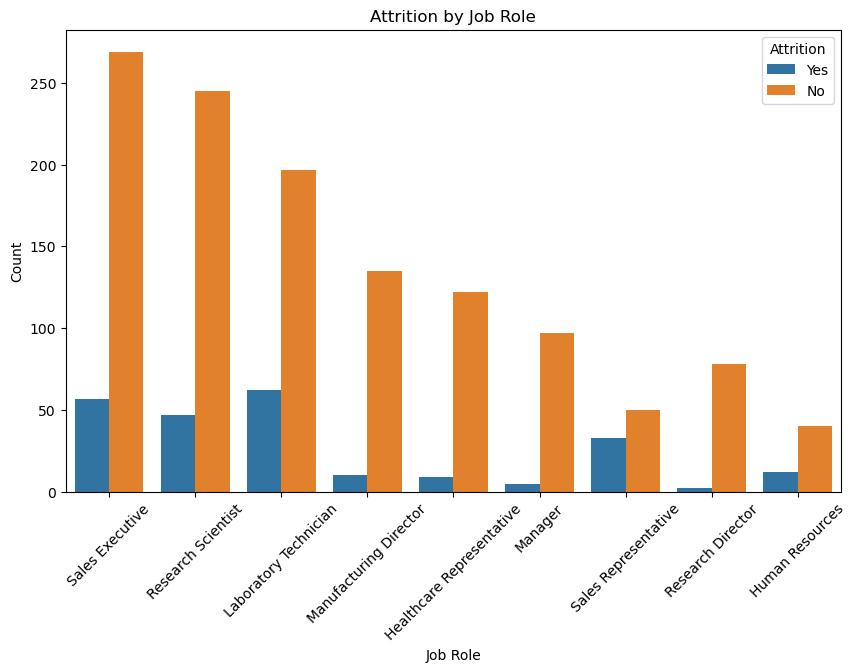

In [22]:
# Job Role vs. Attrition
# Check which job roles have higher attrition
plt.figure(figsize=(10,6))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.title('Attrition by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

The chart shows that attrition levels vary by job role. Sales Executives, Laboratory Technicians, and Research Scientists have the highest number of employees who left the company. In contrast, job roles like Healthcare Representative, Research Director, and Manager have fewer employees leaving. Although all roles have more employees who stayed, some roles clearly show higher attrition, especially in sales and lab positions. This suggests that job type can influence employee turnover

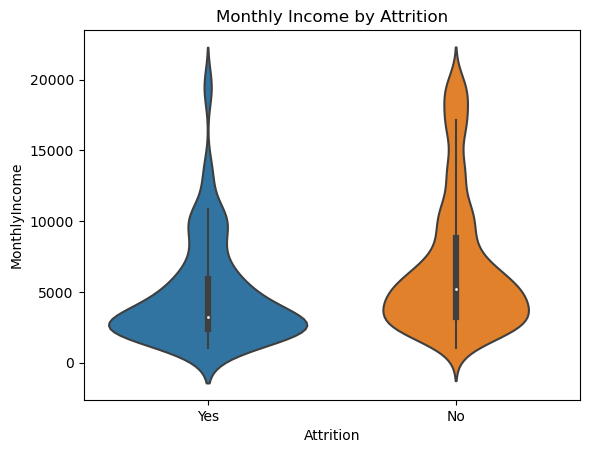

In [27]:
sns.violinplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income by Attrition")
plt.show()

The violin plot shows the distribution of monthly income for employees who stayed versus those who left. Employees who left the company  generally have lower monthly income compared to those who stayed. Most of the employees who left earn between $2,000 and $5,000, while employees who stayed show a wider spread and include more high-income earners above $10,000. Although both groups have similar ranges, the distribution for the "No" group  is more stretched, suggesting that higher income may be linked to lower attrition. 

## MILESTONE 2: DATA PREPARATION

#### 1. Check and handle missing data
Since there is no missing values in this dataset, no imputation needed. 
#### 2. Drop useless features 
- EmployeeCount: All values are 1.
- Over18: All values are 'Y'.
- StandardHours: All values are 80.
- EmployeeNumber: Just an ID, adds no value.

These features don’t help prediction and should be removed

In [34]:
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)

#### 3. Convert target variable 'Attrition' to binary 

1 = Yes 

0 = No 

In [37]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

#### 4. Create dummy variables
Convert categorical columns into numeric dummy variables. 

In [40]:
df = pd.get_dummies(df, drop_first=True)

In [42]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


## MILESTONE 3: MODEL BUILDING AND EVALUATION

In [45]:
# See the percentage of each class
attrition_percent = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_percent)

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


In [47]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Split before applying SMOTE 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

SMOTE is applied because the dataset is imbalanced, with only about 16% attrition, this means far more employees staying than leaving. This imbalance can cause the model to favor the majority class (those who stay), leading to poor performance in predicting employee attrition. SMOTE creates synthetic examples of the minority class (employees who leave), helping the model learn patterns from both classes more effectively.

#### 1. Train LOGISTIC REGRESSION model

In [51]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_scaled, y_train_smote)
log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

#### 2. Train RANDOM FOREST model

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train_smote)
rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

#### 3. Train XGBOOST model

In [57]:
!pip install xgboost

In [58]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train_smote)
xgb_preds = xgb_model.predict(X_test_scaled)
xgb_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

#### 4. Evaluate models 


Logistic Regression Results:
Accuracy: 0.8571428571428571
Confusion Matrix:
 [[232  15]
 [ 27  20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       247
           1       0.57      0.43      0.49        47

    accuracy                           0.86       294
   macro avg       0.73      0.68      0.70       294
weighted avg       0.84      0.86      0.85       294


Random Forest Results:
Accuracy: 0.8231292517006803
Confusion Matrix:
 [[233  14]
 [ 38   9]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.94      0.90       247
           1       0.39      0.19      0.26        47

    accuracy                           0.82       294
   macro avg       0.63      0.57      0.58       294
weighted avg       0.78      0.82      0.80       294


XGBoost Results:
Accuracy: 0.8571428571428571
Confusion Matrix:
 [[237  10]
 [ 32  15]]
Classificatio

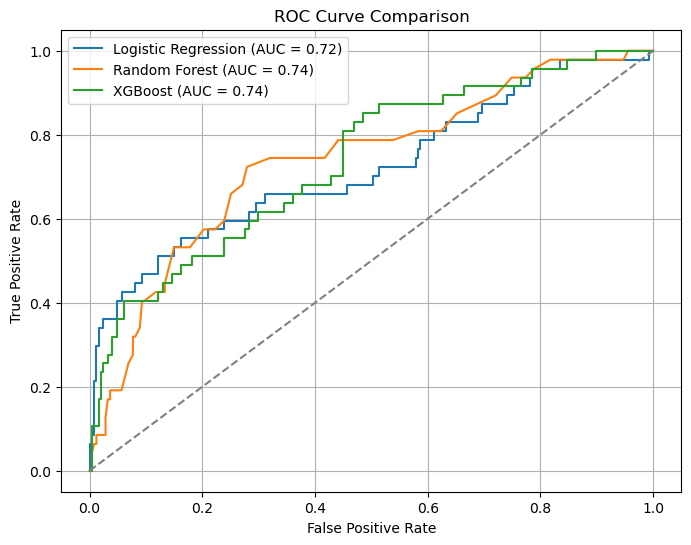

In [60]:
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_curve, auc
)

# Define Evaluation function 
def evaluate_model(name, y_true, y_pred, y_probs):
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")


# Run evaluations and plot ROC Curve 
plt.figure(figsize=(8, 6))

evaluate_model("Logistic Regression", y_test, log_preds, log_probs)
evaluate_model("Random Forest", y_test, rf_preds, rf_probs)
evaluate_model("XGBoost", y_test, xgb_preds, xgb_probs)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

All three models achieved solid overall accuracy (>80%), but their performance on predicting employee attrition (the minority class) varied significantly. Logistic Regression had the best balance, with the highest F1-score (0.49) and the best recall (0.43), making it more reliable for identifying employees at risk of leaving. Random Forest had the lowest recall (0.19), indicating it missed most attrition cases, though it performed well on the majority class. XGBoost improved precision to 0.60 and matched the highest AUC score (0.74), showing strong overall ranking ability. However, its recall (0.32) was still lower than Logistic Regression. Therefore, while XGBoost offers a more powerful modeling approach, Logistic Regression remains the most dependable option for this case, especially when recall and balanced detection are important.
